# Lab 2: Population Analysis

Goals:

* Learn how to pick out subpopulations
* Analyze the binaries in your subpopulation, understand their evolution history and formation channels
* Learn how to vary the parameters of your population and produce different outcomes

___

In this lab we are going to look at a much larger population than what we have done so far. The population that we will look at consists of 1,000,000 binaries and although you now know how to run a population like this yourself, it can take something like an hour to run on an HPC facility, depending on available resources. So, we'll simply load in a pre-run population and analyze it below -- we'll keep things simple for now and stick to one metallicity, but later on in this lab you will see how to work with a multi-metallicity population. First up, let's import the `Population` class so that we can begin our analysis.

# 1. Managing Large Binary Populations

As we have alluded to, you will probably be running much larger populations than what we have been running when you use POSYDON in your own research. This is essential in order to get realistic statistics on the populations that you might be interested in. So, we will get some practice now how to handle very large populations. In the last lab, you may have gotten to the point of running a population on an HPC system. This essentially picks up from that point, but we will pretend that you ran a population of 1 million stars (even this is on the smaller side in comparison to real stellar populations in nature). Running populations this large will usually require HPC usage (unless you have a lot of time or a very fast PC!). On quest, a population this size completed within a few hours, but this timeframe can be more or less depending on your available system resources.

Thankfully, much of what you have seen already applies here as well -- just everything is bigger. Also, since we're using more than 10 or 100 stars, we can start to see some accurate physical results, based on the underlying physical assumptions made in POSYDON.

## 1.1 Loading Your Population

After you've run a population, you'll be met with its save file in your working directory. We have one prepared for you to load up and begin inspecting. 

In [2]:
from posydon.popsyn.synthetic_population import Population

#### Exercise 1: Load in the population

1. Load the population into memory using the path provided below.
2. Print out the population's initial parameters to see the settings used to create it
3. Have a look at the history data frame (and a few binaries for fun, if you like)

In [3]:
path_to_pop = "/mnt/d/Research/POSYDON_popsynth/test_1M/1e+00_Zsun_population.h5"
pop = Population(path_to_pop)

Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


In [4]:
pop.ini_params

{'number_of_binaries': 1000000,
 'binary_fraction_scheme': 'const',
 'binary_fraction_const': 0.7,
 'star_formation': 'burst',
 'max_simulation_time': 13800000000.0,
 'primary_mass_scheme': 'Kroupa2001',
 'primary_mass_min': 7.0,
 'primary_mass_max': 150.0,
 'secondary_mass_scheme': 'flat_mass_ratio',
 'secondary_mass_min': 0.5,
 'secondary_mass_max': 150.0,
 'orbital_scheme': 'period',
 'orbital_period_scheme': 'Sana+12_period_extended',
 'orbital_period_min': 0.75,
 'orbital_period_max': 6000.0,
 'eccentricity_scheme': 'zero'}

In [5]:
pop.mass_per_metallicity

,simulated_mass,simulated_mass_single,simulated_mass_binaries,number_of_systems
metallicity,,,,
1.0,2.543969e+07,5.587543e+06,1.985214e+07,1000000


In [6]:
cols = ['time', 'step_names', 'state', 'event', 'S1_state', 'S2_state', 'S1_mass', 'S2_mass', 'orbital_period']
pop.history[12039][cols]

,time,step_names,state,event,S1_state,S2_state,S1_mass,S2_mass,orbital_period
binary_index,,,,,,,,,
12039,0.000000e+00,initial_cond,detached,ZAMS,H-rich_Core_H_burning,H-rich_Core_H_burning,8.630837,3.686910,508.549059
12039,3.588222e+07,step_HMS_HMS,RLO1,oCE1,H-rich_Shell_H_burning,H-rich_Core_H_burning,7.624719,3.701142,389.964470
12039,3.588222e+07,step_CE,merged,oMerging1,H-rich_Shell_H_burning,H-rich_Core_H_burning,7.624719,3.701142,389.964470
12039,3.726845e+07,step_merged,merged,CC1,H-rich_Core_C_depleted,massless_remnant,9.193540,0.000000,NaN
12039,3.726845e+07,step_SN,merged,NaN,NS,massless_remnant,1.544419,0.000000,NaN
12039,3.726845e+07,step_end,merged,END,NS,massless_remnant,1.544419,0.000000,NaN


## 1.2 Masking Your Population

Often when you are using POSYDON you will be interested in looking at a particular type of stellar system that you are researching, or you will simply want to partition all of the population data up into more digestible pieces so that you can work on understanding things piece by piece. We will demonstrate how this can be done, and get familiar with population analysis by setting ourselves the task of picking out all of the binary black hole merger systems in our population and studying some of their basic properties.

You can use all the regular tricks that you might know to maniupulate your population's `DataFrame`s and get out the data that you want. In addition, the `history` of your `Population` has a nice function called `select` that lets you easily cut your `DataFrame` based on some logic that you define, or just specific data columns that you specify. This can be useful for a number of reasons; one of which is that you may notice our history `DataFrame` for this population is huge! If you try to look at it by running the code below, it should take several seconds (up to a minute) to run before it outputs the data to your notebook.

In [7]:
pop.history[cols]

,time,step_names,state,event,S1_state,S2_state,S1_mass,S2_mass,orbital_period
binary_index,,,,,,,,,
0,0.000000e+00,initial_cond,initially_single_star,ZAMS,H-rich_Core_H_burning,massless_remnant,12.704623,0.0000,NaN
0,1.905093e+07,step_initially_single,initially_single_star,CC1,H-rich_Core_C_depleted,massless_remnant,9.385612,0.0000,NaN
0,1.905093e+07,step_SN,initially_single_star,NaN,NS,massless_remnant,1.782991,0.0000,NaN
0,1.905093e+07,step_end,initially_single_star,END,NS,massless_remnant,1.782991,0.0000,NaN
1,0.000000e+00,initial_cond,initially_single_star,ZAMS,H-rich_Core_H_burning,massless_remnant,13.369053,0.0000,NaN
...,...,...,...,...,...,...,...,...,...
999998,1.113029e+08,step_end,merged,END,massless_remnant,WD,0.000000,1.0818,NaN
999999,0.000000e+00,initial_cond,initially_single_star,ZAMS,H-rich_Core_H_burning,massless_remnant,11.731645,0.0000,NaN
999999,2.169656e+07,step_initially_single,initially_single_star,CC1,H-rich_Core_C_depleted,massless_remnant,9.163302,0.0000,NaN


Running around with all this data is cumbersome if you don't need it. We can cut it down to size using `select()` to pick out just the things we will need for now. For example, if our first task is to find all of the binary black holes in this population, we really only need the star states and the binary `event`. We can cut our `DataFrame` to include just those like this, with the `columns` argument of `select()`:

In [8]:
# temporarily store the cut history DataFrame for easy access/clarity
tmp_data = pop.history.select(columns=['S1_state', 'S2_state', 'event'])

If you try displaying this in your notebook, you should notice it takes much less time, as we are carrying around considerably less data.

In [9]:
tmp_data

,S1_state,S2_state,event
binary_index,,,
0,H-rich_Core_H_burning,massless_remnant,ZAMS
0,H-rich_Core_C_depleted,massless_remnant,CC1
0,NS,massless_remnant,NaN
0,NS,massless_remnant,END
1,H-rich_Core_H_burning,massless_remnant,ZAMS
...,...,...,...
999998,massless_remnant,WD,END
999999,H-rich_Core_H_burning,massless_remnant,ZAMS
999999,H-rich_Core_C_depleted,massless_remnant,CC1


With that out of the way, we can work on getting our merging binary black holes.

### 1.2.1 Designing a Simple BBH Mask

Above, we just saw how we can cut our data down to a more manageable size using the `select` function. This is one way to maks your data and pick out just what you want. However, since we are working with `DataFrame`s, we can utilize all of the same functionalities that you normally would for manipulating those data structures. In this section, you will design your own mask to select merging binary black hole systems using conventional `DataFrame` manipulation techniques and POSYDON's `select()` function.

#### Exercise 2: Masking a population for merging black holes
* (a) Using the `event`, `S1_state`, and `S2_state`, define a mask to find the binary indices of all merging BBH systems. (**Hint: the `event` you want is called `CO_contact`.**)
* (b) Try doing the same thing using the `pop.history.select()` function. More instructions on this below.

#### Ex. 2: Part (a)

In [10]:
# Define a mask to slice out just systems that have merging black holes:
S1_is_BH = tmp_data['S1_state'] == 'BH' # Fill this in
S2_is_BH = tmp_data['S2_state'] == 'BH' # Fill this in
is_merging = tmp_data['event'] == 'CO_contact' # This can be given

mask = S1_is_BH & S2_is_BH & is_merging

# get the indices of all systems
indices = tmp_data.index

# Use your mask to get just the binary indices for BBH systems
BBH_indices = indices[mask].to_list()

Now we should have all the indices of the systems that we are after. We can check by running this (it will take a bit of time to run again):

#### Below, check that you have successfully masked your population to contain only merging binary black hole systems:

In [12]:
pop.history[BBH_indices][cols]

,time,step_names,state,event,S1_state,S2_state,S1_mass,S2_mass,orbital_period
binary_index,,,,,,,,,
2238,0.000000e+00,initial_cond,detached,ZAMS,H-rich_Core_H_burning,H-rich_Core_H_burning,30.912433,27.653125,2.351478e+01
2238,6.726530e+06,step_HMS_HMS,detached,CC1,stripped_He_Core_C_depleted,H-rich_Core_H_burning,10.130899,24.428460,4.760350e+01
2238,6.726530e+06,step_SN,detached,NaN,BH,H-rich_Core_H_burning,7.643245,24.428460,6.193340e+02
2238,6.884699e+06,step_detached,RLO2,oRLO2,BH,H-rich_Shell_H_burning,7.643245,24.062474,4.340114e+01
2238,6.885764e+06,step_CO_HMS_RLO,RLO2,oCE2,BH,H-rich_Shell_H_burning,7.643619,23.245902,3.701053e+01
...,...,...,...,...,...,...,...,...,...
998980,7.069116e+06,step_CE,detached,NaN,BH,stripped_He_non_burning,10.704601,10.358797,7.627977e-01
998980,7.684018e+06,step_CO_HeMS,detached,CC2,BH,stripped_He_Core_C_depleted,10.704601,6.950129,1.087289e+00
998980,7.684018e+06,step_SN,detached,NaN,BH,BH,10.704601,3.709329,2.078472e+00


It should look  right, but you won't be able to see everything since the `DataFrame` gets truncated. Just looking at one system:

#### Below, examine just a single BBH system's history DataFrame and check that it looks right:

In [13]:
pop.history[BBH_indices[0]][cols]

,time,step_names,state,event,S1_state,S2_state,S1_mass,S2_mass,orbital_period
binary_index,,,,,,,,,
2238,0.000000e+00,initial_cond,detached,ZAMS,H-rich_Core_H_burning,H-rich_Core_H_burning,30.912433,27.653125,2.351478e+01
2238,6.726530e+06,step_HMS_HMS,detached,CC1,stripped_He_Core_C_depleted,H-rich_Core_H_burning,10.130899,24.428460,4.760350e+01
2238,6.726530e+06,step_SN,detached,NaN,BH,H-rich_Core_H_burning,7.643245,24.428460,6.193340e+02
2238,6.884699e+06,step_detached,RLO2,oRLO2,BH,H-rich_Shell_H_burning,7.643245,24.062474,4.340114e+01
2238,6.885764e+06,step_CO_HMS_RLO,RLO2,oCE2,BH,H-rich_Shell_H_burning,7.643619,23.245902,3.701053e+01
2238,6.885764e+06,step_CE,detached,NaN,BH,stripped_He_non_burning,7.643619,11.468457,1.258734e-01
2238,7.493159e+06,step_CO_HeMS,detached,CC2,BH,stripped_He_Core_C_depleted,7.164328,6.447991,2.028407e-01
2238,7.493159e+06,step_SN,detached,NaN,BH,BH,7.164328,2.567101,3.354277e-01
2238,2.305616e+08,step_dco,contact,CO_contact,BH,BH,7.164328,2.567101,9.864484e-09



#### Ex. 2: Part (b)

Let's do all that another way, using the `select()` function. Besides specifying columns that you want to select from your `DataFrame`, you can also give `select()` a logic statement to pick out systems.

In [14]:
# We can make up just about anything we want for the logic -- its a string. 
# The string has to follow valid Python logic syntax, and we're restricted to utilize the data available in our history DataFrame though.
# Here's something simple to get merging NS-BH pairs:
logic_statement = "(event == CO_contact) & (S1_state == BH) & (S2_state == BH)" # Have students fill this in

df = pop.history.select(where=logic_statement)

BBH_indices = df.index.to_list()

The two resulting list of indices should be the same. What we've done is to use the `select()` function to pick out just the rows where we have two black holes and the event is such that the two compact objects are merging. 

#### Take a look at your `select`ed `DataFrame` below to see this for yourself:

In [15]:
df

,state,event,time,orbital_period,eccentricity,lg_mtransfer_rate,step_names,step_times,S1_state,S1_mass,...,S2_he_core_mass,S2_he_core_radius,S2_co_core_mass,S2_co_core_radius,S2_center_h1,S2_center_he4,S2_surface_h1,S2_surface_he4,S2_surf_avg_omega_div_omega_crit,S2_spin
binary_index,,,,,,,,,,,,,,,,,,,,,
2238,contact,CO_contact,2.305616e+08,9.864484e-09,0.0,NaN,step_dco,0.748639,BH,7.164328,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.105775
3326,contact,CO_contact,4.629188e+09,1.443192e-08,0.0,NaN,step_dco,0.569720,BH,10.509954,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.143248
3420,contact,CO_contact,9.768917e+09,1.598573e-08,0.0,NaN,step_dco,0.606465,BH,12.065234,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.037342
4359,contact,CO_contact,4.935756e+09,1.522043e-08,0.0,NaN,step_dco,0.578913,BH,11.310278,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.037342
5885,contact,CO_contact,1.185940e+09,1.304417e-08,0.0,NaN,step_dco,0.579698,BH,9.273201,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.190751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992352,contact,CO_contact,1.151877e+10,1.572617e-08,0.0,NaN,step_dco,0.546961,BH,10.388210,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.035111
993252,contact,CO_contact,2.481032e+09,1.423125e-08,0.0,NaN,step_dco,0.595627,BH,10.329920,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.030592
996122,contact,CO_contact,1.085543e+10,1.230880e-08,0.0,NaN,step_dco,0.565047,BH,8.283876,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.088313


and if you use you run the same code as before to look at one of your merging BBH systems, you should see that the index list that you've found yields the exact same results as before:

In [16]:
pop.history[BBH_indices[0]][cols]

,time,step_names,state,event,S1_state,S2_state,S1_mass,S2_mass,orbital_period
binary_index,,,,,,,,,
2238,0.000000e+00,initial_cond,detached,ZAMS,H-rich_Core_H_burning,H-rich_Core_H_burning,30.912433,27.653125,2.351478e+01
2238,6.726530e+06,step_HMS_HMS,detached,CC1,stripped_He_Core_C_depleted,H-rich_Core_H_burning,10.130899,24.428460,4.760350e+01
2238,6.726530e+06,step_SN,detached,NaN,BH,H-rich_Core_H_burning,7.643245,24.428460,6.193340e+02
2238,6.884699e+06,step_detached,RLO2,oRLO2,BH,H-rich_Shell_H_burning,7.643245,24.062474,4.340114e+01
2238,6.885764e+06,step_CO_HMS_RLO,RLO2,oCE2,BH,H-rich_Shell_H_burning,7.643619,23.245902,3.701053e+01
2238,6.885764e+06,step_CE,detached,NaN,BH,stripped_He_non_burning,7.643619,11.468457,1.258734e-01
2238,7.493159e+06,step_CO_HeMS,detached,CC2,BH,stripped_He_Core_C_depleted,7.164328,6.447991,2.028407e-01
2238,7.493159e+06,step_SN,detached,NaN,BH,BH,7.164328,2.567101,3.354277e-01
2238,2.305616e+08,step_dco,contact,CO_contact,BH,BH,7.164328,2.567101,9.864484e-09


#### Does the history DataFrame above match the binary history that you found before in part (a)?

## 1.3 Exporting your population selection to a file

Now that we've picked out our BBH systems, we can save our selection to a file, making it easier to come back and work on things if we have to give it a rest at some point. To do this, we can use the `export_selection()` function of the `Population` class to save our BBH systems to a `.h5` file. It is as simple as:

In [17]:
pop.export_selection(BBH_indices, '1e+00_Zsun_BBH_contact_subpop.h5', append=True)

Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


If you look inside of your working directory, you should find your new subpopulation file there. It's the same thing as a regular population file, just containing only the systems that you've selected: the merging binary black holes.

# 2. Analyzing a population of merging black holes

At this point, you probably know how to get started. Let's load our populations up, just like if we'd started a new day at the office and we're excited to find out what happened in our simulation of BBH systems.

In [18]:
BBH_pop = Population('1e+00_Zsun_BBH_contact_subpop.h5')

Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


If we look at the mass per metallicity meta data of our population, we can see a few interesting things already.

In [19]:
BBH_pop.mass_per_metallicity

,simulated_mass,simulated_mass_single,simulated_mass_binaries,number_of_systems
metallicity,,,,
1.0,5.087937e+07,1.117509e+07,3.970428e+07,1182


Out of 1 million binaries, we only got several hundred merging BBH systems (in this case, about 0.06% of the total population). So, these do indeed seem like pretty rare systems to find, just like what we see in nature.

There are many things that we could do at this point, and we will leave some for later in the week. For now, let's try and look at the mass distribution of our BBH systems. To start with, import `matplotlib.pyplot` for some basic plotting functionality.

In [57]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

## 2.1 Plotting Distributions

You will often want to take a look at various distributions in your population. Such as their mass or orbital period distribution to compare to real data. Below, we will work on an example of how you might do this with your merging binary black hole population. POSYDON does have some built-in plotting functionalities that you will see later in the week. However, you will often be using Python's usual packages for making plots tailored to suit your specific research needs. You will have to run, load, and manipulate your data to analyze whatever it is you are interested in. You've already done the first couple of those steps, so in this next exercise you can practice with the last step: plotting and analyzing.

#### Exercise 3: Plotting the BBH mass distribution

1. Make a histogram of the primary black hole mass distribution at solar metallicity.
2. We have another population file available from 1 million binaries run at a lower metallicity. Load it in and export the BBH population.
3. Plot the mass distribution of the lower metallicity population, and compare to solar metallicity.
4. Note any differences and reasons for them.

#### Ex. 3: Part 1

In [58]:
logic_statement = "(event == CO_contact) & (S1_state == BH) & (S2_state == BH)"

BBH_at_contact = BBH_pop.history.select(where=logic_statement)

In [59]:
# Might need to do this to avoid tex errors
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

In [60]:
BBH_m1 = BBH_at_contact['S1_mass']
BBH_m2 = BBH_at_contact['S2_mass']

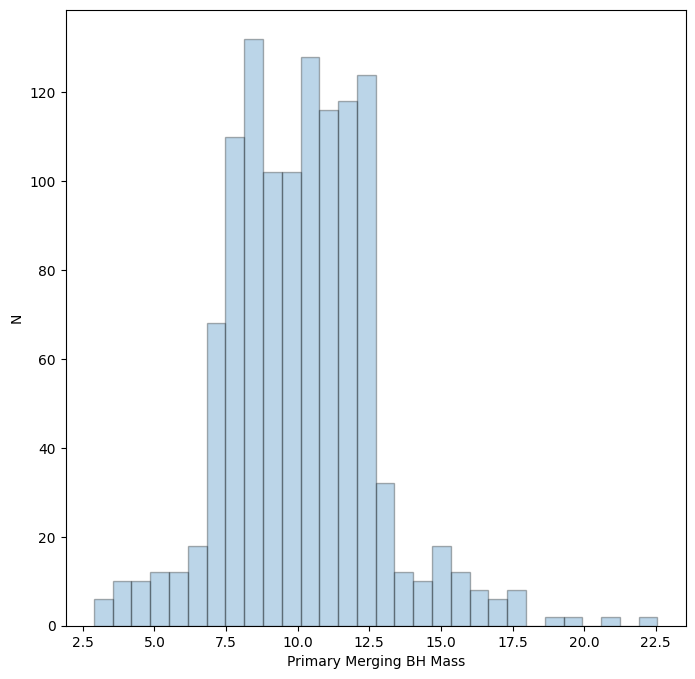

In [61]:
f, ax = plt.subplots(1,1, figsize=(8,8))

ax.hist(BBH_m1, bins=30, alpha = 0.3, ec='k')
ax.set_ylabel("N")
ax.set_xlabel("Primary Merging BH Mass")

plt.show()

#### Ex. 3: Part 2 (Load the low Z population and export the merging BBH subpopulation)

In [25]:
path_to_pop = "/mnt/d/Research/POSYDON_popsynth/test_1M/1e-04_Zsun_population.h5"
lowZ_pop = Population(path_to_pop)

Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


In [26]:
lowZ_pop.mass_per_metallicity

,simulated_mass,simulated_mass_single,simulated_mass_binaries,number_of_systems
metallicity,,,,
0.0001,2.540883e+07,5.565687e+06,1.984315e+07,1000000


In [27]:
logic_statement = "(event == CO_contact) & (S1_state == BH) & (S2_state == BH)" # Have students fill this in

df = lowZ_pop.history.select(where=logic_statement)

BBH_indices = df.index.to_list()

In [28]:
lowZ_pop.history[BBH_indices[0]]

,state,event,time,orbital_period,eccentricity,lg_mtransfer_rate,step_names,step_times,S1_state,S1_mass,...,S2_he_core_mass,S2_he_core_radius,S2_co_core_mass,S2_co_core_radius,S2_center_h1,S2_center_he4,S2_surface_h1,S2_surface_he4,S2_surf_avg_omega_div_omega_crit,S2_spin
binary_index,,,,,,,,,,,,,,,,,,,,,
80,detached,ZAMS,0.000000e+00,3.175495e+02,0.000000,NaN,initial_cond,0.000000,H-rich_Core_H_burning,23.497669,...,NaN,NaN,NaN,NaN,0.750999,2.490000e-01,NaN,NaN,NaN,NaN
80,RLO1,CC1,8.700180e+06,5.205734e+02,0.000000,-3.890041,step_HMS_HMS,0.136683,H-rich_Core_C_depleted,12.457509,...,0.000000,0.000000,0.000000,0.000000,0.270713,7.292852e-01,4.103369e-01,0.589661,0.941193,11.047408
80,detached,NaN,8.700180e+06,3.927609e+02,0.462147,NaN,step_SN,0.000461,BH,7.749390,...,0.000000,0.000000,0.000000,0.000000,0.270713,7.292852e-01,4.103369e-01,0.589661,0.941193,11.047408
80,RLO2,oRLO2,1.134945e+07,1.553529e+02,0.000000,NaN,step_detached,0.488808,BH,7.749390,...,7.855667,NaN,6.541635,0.230352,0.000000,4.022569e-04,7.509986e-01,0.248974,0.809285,9.788417
80,RLO2,oCE2,1.135222e+07,1.227558e+02,0.000000,-2.347902,step_CO_HMS_RLO,0.062222,BH,7.750112,...,7.895390,0.312569,6.579357,0.225066,0.000000,2.811886e-07,7.503941e-01,0.249584,0.099941,1.838920
80,detached,NaN,1.135222e+07,2.021366e-01,0.000000,NaN,step_CE,0.000242,BH,7.750112,...,7.895390,0.312569,6.579357,0.225066,0.000000,2.811886e-07,1.000000e-02,0.989999,NaN,NaN
80,detached,CC2,1.206468e+07,1.993291e-01,0.000000,-84.812564,step_CO_HeMS,1.857913,BH,7.750112,...,7.855230,0.890472,5.898388,0.094092,0.000000,1.550784e-12,2.976746e-24,0.999984,0.320361,0.602203
80,detached,NaN,1.206468e+07,5.131404e-01,0.411854,NaN,step_SN,0.000581,BH,7.750112,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.088053
80,contact,CO_contact,3.227312e+08,1.173167e-08,0.000000,NaN,step_dco,0.816018,BH,7.750112,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.088053


In [29]:
lowZ_pop.export_selection(BBH_indices, '1e-04_Zsun_BBH_contact_subpop.h5', append=True)

Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


#### Ex. 3: Part 3 (Plot the low Z BBH merging primary mass distribution)

In [30]:
lowZ_BBH_pop = Population('1e-04_Zsun_BBH_contact_subpop.h5')

Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


In [31]:
lowZ_BBH_pop.mass_per_metallicity

,simulated_mass,simulated_mass_single,simulated_mass_binaries,number_of_systems
metallicity,,,,
0.0001,5.081766e+07,1.113137e+07,3.968629e+07,24144


In [32]:
logic_statement = "(event == CO_contact) & (S1_state == BH) & (S2_state == BH)"

lowZ_BBH_at_contact = lowZ_BBH_pop.history.select(where=logic_statement)

In [33]:
lowZ_BBH_m1 = lowZ_BBH_at_contact['S1_mass']
lowZ_BBH_m2 = lowZ_BBH_at_contact['S2_mass']

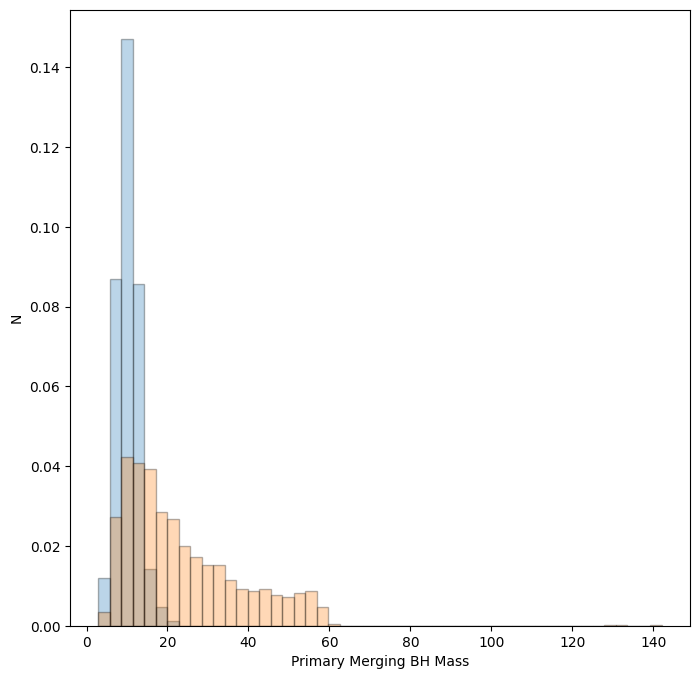

In [62]:
f, ax = plt.subplots(1,1, figsize=(8,8))

bins = np.linspace(min(BBH_m1.min(), lowZ_BBH_m1.min()), max(BBH_m1.max(), lowZ_BBH_m1.max()), 50)

ax.hist(BBH_m1, bins=bins, alpha = 0.3, ec='k',density=True)
ax.hist(lowZ_BBH_m1, bins=bins, alpha = 0.3, ec='k',density=True)
ax.set_ylabel("N")
ax.set_xlabel("Primary Merging BH Mass")

plt.show()

#### Ex. 3: Part 4 (Note the differences between the populations)

There's not much to do here in code, but take some time to think through what could be causing the differences in the two populations above and talk to your neighbors or the TAs (if they aren't too busy). How do the populations that you see compare to results from the literature? An analysis can get much more complicated, with all of the data available in POSYDON, and ideally we would run a much larger population in a real analysis. The other classes during the week will build on what you have learned here and go into more depth on the different evolution steps and analysis capabilities of POSYDON.

Now, let's take a look at how we can robustly determine the formation channels of our BBH subpopulation.

## 2.2 Inspecting Formation Channels

One thing that we have not seen is how you can calculate the formation channels of binaries in your population. While you can always look at the history of your binaries and get an idea of the formation channel yourself, POSYDON does have an automated way to pick out and sumamrize this information for you. Here is how:

In [35]:
# Calculate the formation channels for our BBH pop
BBH_pop.calculate_formation_channels()

After calculating the formation channels, they are automatically saved in your population's `.h5` file to access later. Anytime you load up your population now, you can access the formation channels like this:

In [36]:
BBH_pop.formation_channels

,channel_debug,channel
0,ZAMS_oRLO1_CC1_oRLO2_oCE2_CC2_CO_contact_END,ZAMS_oRLO1_CC1_oRLO2_oCE2_CC2_END
1,ZAMS_oRLO1_CC1_oRLO2_oCE2_CC2_CO_contact_END,ZAMS_oRLO1_CC1_oRLO2_oCE2_CC2_END
2,ZAMS_oRLO1_CC1_oRLO2_oCE2_CC2_CO_contact_END,ZAMS_oRLO1_CC1_oRLO2_oCE2_CC2_END
3,ZAMS_oRLO1_CC1_oRLO2_oCE2_CC2_CO_contact_END,ZAMS_oRLO1_CC1_oRLO2_oCE2_CC2_END
4,ZAMS_oRLO1_CC1_oRLO2_oCE2_CC2_CO_contact_END,ZAMS_oRLO1_CC1_oRLO2_oCE2_CC2_END
...,...,...
1177,ZAMS_oRLO1_CC1_oRLO2_oCE2_CC2_CO_contact_END,ZAMS_oRLO1_CC1_oRLO2_oCE2_CC2_END
1178,ZAMS_oRLO1_CC1_oRLO2_oCE2_CC2_CO_contact_END,ZAMS_oRLO1_CC1_oRLO2_oCE2_CC2_END
1179,ZAMS_oRLO1_CC1_oRLO2_CC2_CO_contact_END,ZAMS_oRLO1_CC1_oRLO2_CC2_END
1180,ZAMS_oRLO1_CC1_oRLO2_oCE2_CC2_CO_contact_END,ZAMS_oRLO1_CC1_oRLO2_oCE2_CC2_END


The `DataFrame` above shows you two columns `channel_debug` and `channel`; we want to pay attention to the one on the right. This column shows us the formation channel for each binary in our population, summarzing how it became a merger. For example, you should see in the first row that binary `0` formed like this:

1. ZAMS (they all start here)
2. The primary star initiates Roche lobe overflow (stable mass transfer)
3. The primary star reach core collapse
4. The secondary eventually initiates Roche lobe overflow (unstable mass transfer)
5. A common envelope (CE) occurs, initated by the secondary
6. The binary survives the CE, the secondary core collapses
7. The two black holes inspiral and merge

You can always refer back to the history for more details. Once again, for this particular binary:

In [37]:
BBH_pop.history[0][cols]

,time,step_names,state,event,S1_state,S2_state,S1_mass,S2_mass,orbital_period
binary_index,,,,,,,,,
0,0.000000e+00,initial_cond,detached,ZAMS,H-rich_Core_H_burning,H-rich_Core_H_burning,30.912433,27.653125,2.351478e+01
0,6.726530e+06,step_HMS_HMS,detached,CC1,stripped_He_Core_C_depleted,H-rich_Core_H_burning,10.130899,24.428460,4.760350e+01
0,6.726530e+06,step_SN,detached,NaN,BH,H-rich_Core_H_burning,7.643245,24.428460,6.193340e+02
0,6.884699e+06,step_detached,RLO2,oRLO2,BH,H-rich_Shell_H_burning,7.643245,24.062474,4.340114e+01
0,6.885764e+06,step_CO_HMS_RLO,RLO2,oCE2,BH,H-rich_Shell_H_burning,7.643619,23.245902,3.701053e+01
0,6.885764e+06,step_CE,detached,NaN,BH,stripped_He_non_burning,7.643619,11.468457,1.258734e-01
0,7.493159e+06,step_CO_HeMS,detached,CC2,BH,stripped_He_Core_C_depleted,7.164328,6.447991,2.028407e-01
0,7.493159e+06,step_SN,detached,NaN,BH,BH,7.164328,2.567101,3.354277e-01
0,2.305616e+08,step_dco,contact,CO_contact,BH,BH,7.164328,2.567101,9.864484e-09


The binary is already so close together after the CE event that the secondary's supernova can not unbind the system; it forms a BH and the two merge. Below, we will practice how you can use these formation channels to analyze your population further.

#### Exercise 4: BBH Formation Channels 

* (a) Look at the full, solar-metallicity population and find all the formation channels of BBH mergers. Which are the most common?
* (b) Overplot the mass distributions of the different formation channels. Explain any physical relations or patterns you find.

Repeat the same steps for the lower metallicity population:

* (c) Find the formation channels of BBH mergers. Which ones dominate in this case?
* (d) Overplot the mass distributions of the different formation channels.

* (e) Compare your findings between the solar and sub-solar metallicity populations. How do the dominant formation channels change with metallicity, if at all?

In [39]:
from collections import Counter
Counter(BBH_pop.formation_channels['channel'])

Counter({'ZAMS_oRLO1_CC1_oRLO2_oCE2_CC2_END': 750,
         'ZAMS_oRLO1_CC1_oRLO2_CC2_END': 300,
         'ZAMS_CC1_oRLO2_CC2_END': 44,
         'ZAMS_oDoubleCE1_CC1_CC2_END': 22,
         'ZAMS_CC1_CC2_END': 16,
         'ZAMS_oDoubleCE2_CC1_CC2_END': 14,
         'ZAMS_oRLO1-reverse_CC1_CC2_END': 12,
         'ZAMS_CC1_oRLO2_oCE2_CC2_END': 12,
         'ZAMS_oRLO1-contact_CC1_CC2_END': 6,
         'ZAMS_oRLO1_CC1_CC2_END': 2,
         'ZAMS_oRLO1-reverse_CC1_oRLO2_CC2_END': 2,
         'ZAMS_oRLO1-contact_CC1_oRLO2_CC2_END': 2})

In [77]:
# Get indices of a formation channel
counts = Counter(BBH_pop.formation_channels['channel'])
print(counts.most_common(1))

most_common_channel = counts.most_common(2)[0][0]
sec_most_common_channel = counts.most_common(2)[1][0]

[('ZAMS_oRLO1_CC1_oRLO2_oCE2_CC2_END', 750)]


In [78]:
most_common_i = BBH_pop.formation_channels.loc[BBH_pop.formation_channels['channel'] == most_common_channel].index
sec_most_common_i = BBH_pop.formation_channels.loc[BBH_pop.formation_channels['channel'] == sec_most_common_channel].index

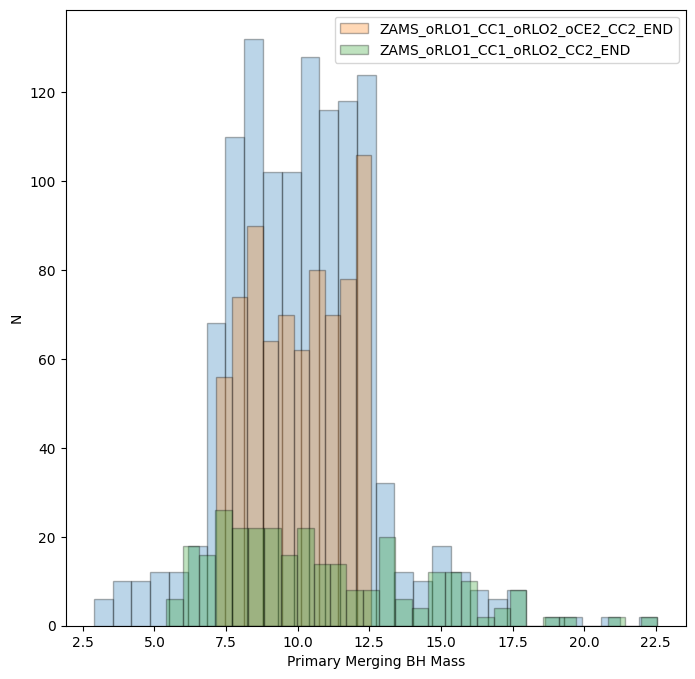

In [80]:
f, ax = plt.subplots(1,1, figsize=(8,8))

ax.hist(BBH_m1, bins=30, alpha = 0.3, ec='k')
ax.hist(BBH_m1[most_common_i], bins=10, alpha = 0.3, ec='k', label=f'{most_common_channel}')
ax.hist(BBH_m1[sec_most_common_i], bins=30, alpha = 0.3, ec='k', label=f'{sec_most_common_channel}')
ax.set_ylabel("N")
ax.set_xlabel("Primary Merging BH Mass")
ax.legend(loc=1)

plt.show()

In [72]:
# Calculate the formation channels for our BBH pop
lowZ_BBH_pop.calculate_formation_channels()

In [73]:
# Get indices of a formation channel
counts = Counter(lowZ_BBH_pop.formation_channels['channel'])
print(counts.most_common(1))

most_common_channel = counts.most_common(2)[0][0]
sec_most_common_channel = counts.most_common(2)[1][0]

[('ZAMS_oRLO1_CC1_oRLO2_CC2_END', 11572)]


In [74]:
most_common_i = lowZ_BBH_pop.formation_channels.loc[lowZ_BBH_pop.formation_channels['channel'] == most_common_channel].index
sec_most_common_i = lowZ_BBH_pop.formation_channels.loc[lowZ_BBH_pop.formation_channels['channel'] == sec_most_common_channel].index

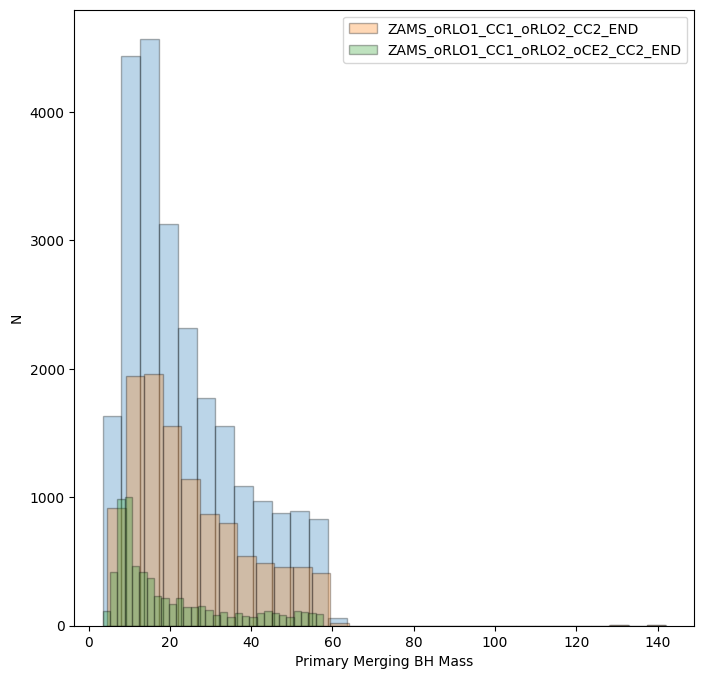

In [75]:
f, ax = plt.subplots(1,1, figsize=(8,8))

ax.hist(lowZ_BBH_m1, bins=30, alpha = 0.3, ec='k')
ax.hist(lowZ_BBH_m1[most_common_i], bins=30, alpha = 0.3, ec='k', label=f'{most_common_channel}')
ax.hist(lowZ_BBH_m1[sec_most_common_i], bins=30, alpha = 0.3, ec='k', label=f'{sec_most_common_channel}')
ax.set_ylabel("N")
ax.set_xlabel("Primary Merging BH Mass")
ax.legend(loc=1)

plt.show()